PART-A Profiling, cleaning, and the data story

In [1]:
## TASK-1
##Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [2]:
###Load dataset
df=sns.load_dataset("titanic")
##save dataset as csv
df.to_csv("titanic.csv",index=False)
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
###Profile datadet
print("Data Information")
print(df.info())

print("\nShape of Datadet")
print(df.shape)

print("\nStastical Summary")
print(df.describe())


Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Shape of Datadet
(891, 15)

Stastical Summary
         s

In [4]:
##Missing value percentage
missing_percentage=(df.isnull().sum()/len(df))*100

missing_df=pd.DataFrame({"Missing Values":df.isnull().sum(),
                         "Percentage":missing_percentage})

missing_df=missing_df[missing_df["Missing Values"]>0]

print(missing_df)

             Missing Values  Percentage
age                     177   19.865320
embarked                  2    0.224467
deck                    688   77.216611
embark_town               2    0.224467


In [5]:
### TASK-2
###Handle missing values
missing_percent=(df.isnull().sum()/len(df))*100

for column in df.columns:
  if missing_percent[column]<5:
    df=df[df[column].notnull()]
  elif 5<=missing_percent[column]<=30:
    if df[column].dtype=="object" or str(df[column].dtype)=="category":
      df[column].fillna(df[column].mode()[0],inplace=True)
    else:
      df[column].fillna(df[column].median(),inplace=True)
  elif missing_percent[column]>30:
    if column=="deck":

      df.drop(columns=[column],inplace=True)
    else:

      df[column].fillna("Missing",inplace=True)
print("Missing values handled successfully!")
print(df.isnull().sum())

Missing values handled successfully!
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


/tmp/ipykernel_552/2870188814.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(),inplace=True)


In [6]:
###save cleaned dataset
df.to_csv("titanic_cleaned.csv",index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


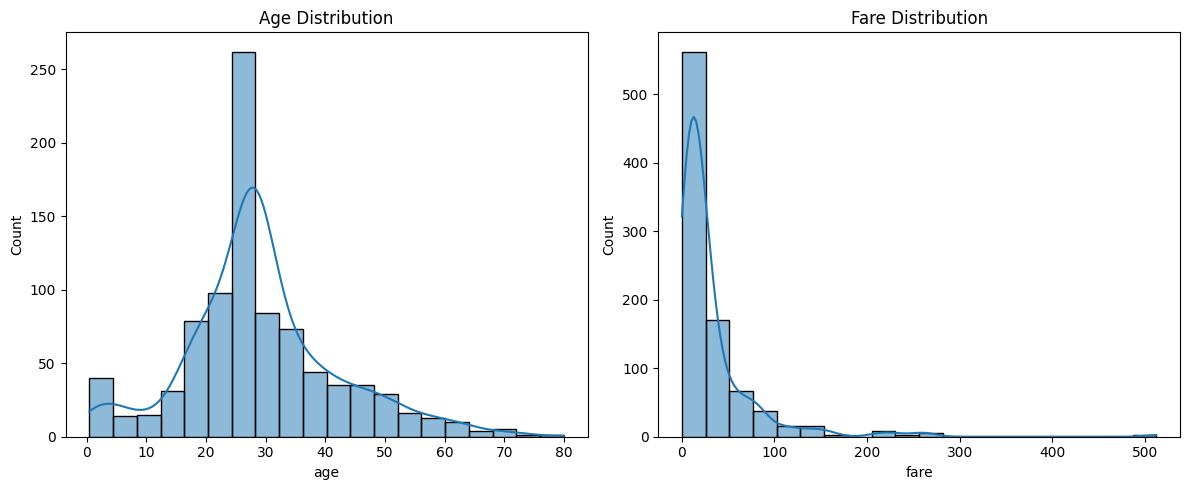

In [7]:
#### TASK-3
##Histogram for Age and Fare
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["age"],bins=20,kde=True)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.histplot(df["fare"],bins=20,kde=True)
plt.title("Fare Distribution")

plt.tight_layout()
plt.show()

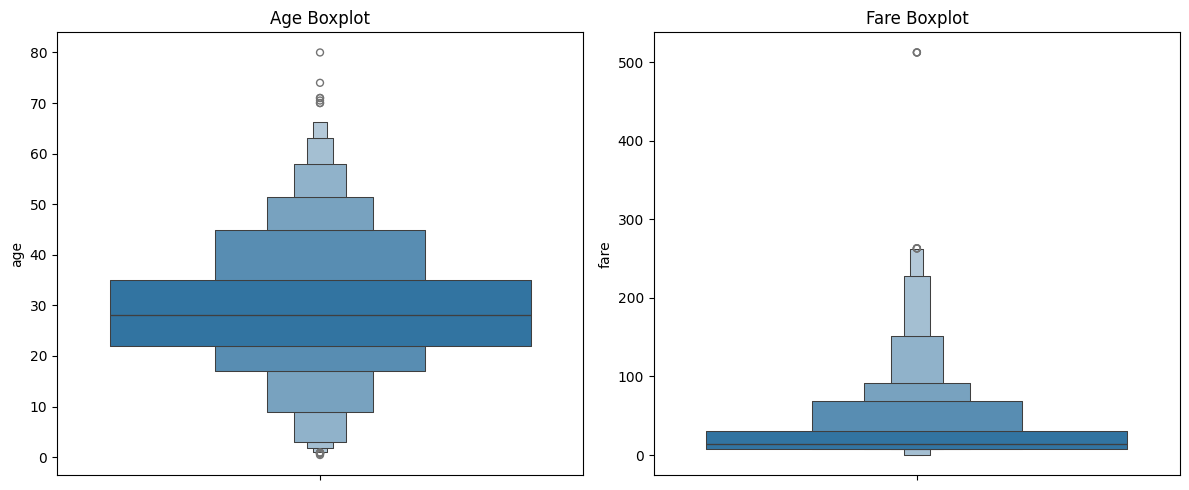

In [8]:
##Boxplots for Age and Fare
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxenplot(y=df["age"])
plt.title("Age Boxplot")

plt.subplot(1,2,2)
sns.boxenplot(y=df["fare"])
plt.title("Fare Boxplot")

plt.tight_layout()
plt.show()

In [9]:
def count_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return lower, upper, len(outliers)


lower, upper, total = count_outliers("age")
print("Age")
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Outliers:", total)

lower, upper, total = count_outliers("fare")
print("\nFare")
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Outliers:", total)

Age
Lower Limit: 2.5
Upper Limit: 54.5
Number of Outliers: 65

Fare
Lower Limit: -26.7605
Upper Limit: 65.6563
Number of Outliers: 114


In [10]:
###Mean,Median and Mode for Fare
print("Mean:",df["fare"].mean())

print("Median:",df["fare"].median())

print("Mode:",df["fare"].mode()[0])

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05


In [11]:
##Skewness
mean=df["fare"].mean()
median=df["fare"].median()
mode=df["fare"].mode()[0]

print("Mean:",mean)
print("Median:",median)
print("mode:",mode)

if mean>median>mode:
  print("Fare Distribution is Right-skewed.")
elif mean<median<mode:
  print("Fare Distribution is Left-skewed.")
else:
  print("Fare Distribution Aporoximately Symmetric.")

Mean: 32.09668087739032
Median: 14.4542
mode: 8.05
Fare Distribution is Right-skewed.


Age: The histogram and boxplot show that most passengers were adults, with a few very young and very old passengers. Some outliers are present in the age distribution.
Fare: The fare distribution is right-skewed because a small number of passengers paid much higher fares than the majority. The boxplot also shows several high-fare outliers.

Survival Rate by Sex
sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


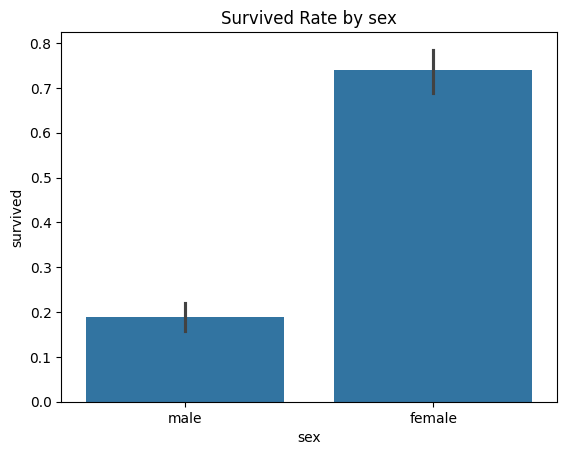

In [12]:
### TASK-4
##Survival Rate by Sex
print("Survival Rate by Sex")
survival_by_sex=df.groupby("sex")["survived"].mean()*100
print(survival_by_sex)

sns.barplot(x="sex",y="survived",data=df)
plt.title("Survived Rate by sex")
plt.show()

Survival rate by passenger Class
pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


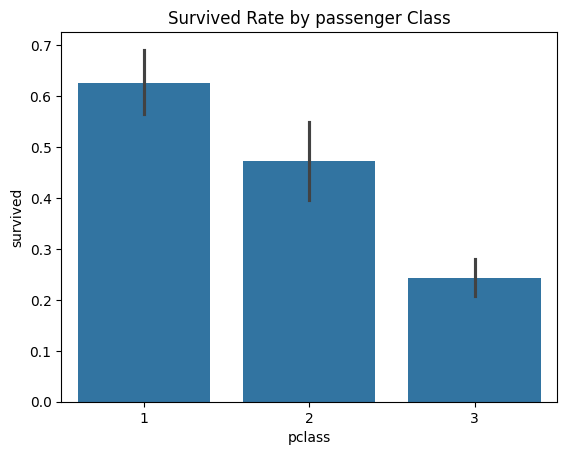

In [13]:
###Survival Rate by Passenger (Pclass)
print("Survival rate by passenger Class")
survival_by_class=df.groupby("pclass")["survived"].mean()*100
print(survival_by_class)

sns.barplot(x="pclass",y="survived",data=df)
plt.title("Survived Rate by passenger Class")
plt.show()


Survival Rate by Sex and Passenger Class
sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


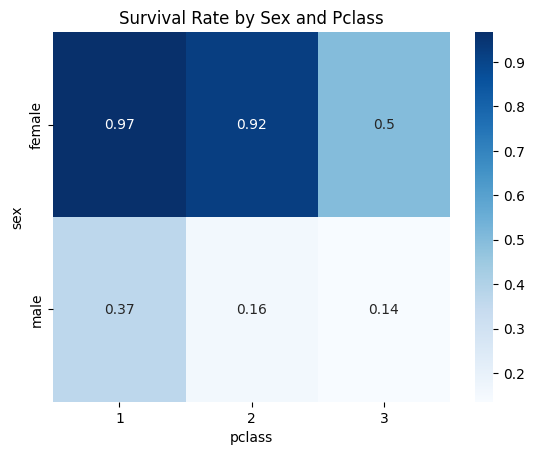

In [14]:
###Survival Rate by Sex and Pclass
print("Survival Rate by Sex and Passenger Class")

survival_by_both = df.groupby(["sex", "pclass"])["survived"].mean() * 100
print(survival_by_both)

pivot = df.pivot_table(values="survived",
                       index="sex",
                       columns="pclass",
                       aggfunc="mean")

sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("Survival Rate by Sex and Pclass")
plt.show()

In [15]:
###correlation matrix
corr_column=["survived","pclass","age","sibsp","parch","fare"]

corr_matrix=df[corr_column].corr()
print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


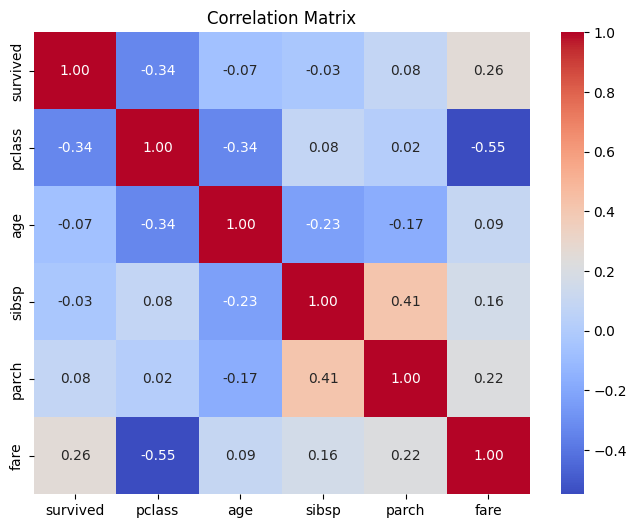

In [16]:
###Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

Survival by Sex: Female passengers had a much higher survival rate than male passengers.
Survival by Pclass: First-class passengers had the highest survival rate, while third-class passengers had the lowest.
Survival by Sex and Pclass: First-class females had the highest survival rate, whereas third-class males had the lowest.
Correlation: The strongest relationships are usually between Pclass and Fare (negative correlation) and Survived and Pclass (negative correlation). The heatmap helps visualize these relationships.

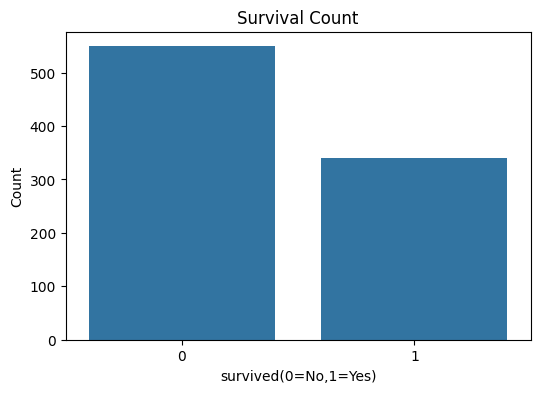

In [17]:
###Task-5
##chart-1 Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x="survived",data=df)
plt.title("Survival Count")
plt.xlabel("survived(0=No,1=Yes)")
plt.ylabel("Count")
plt.show()

Interpretation:
The chat shows the number of passengers who survived and those who did not.More passengers died than survived during the titanic disaster.






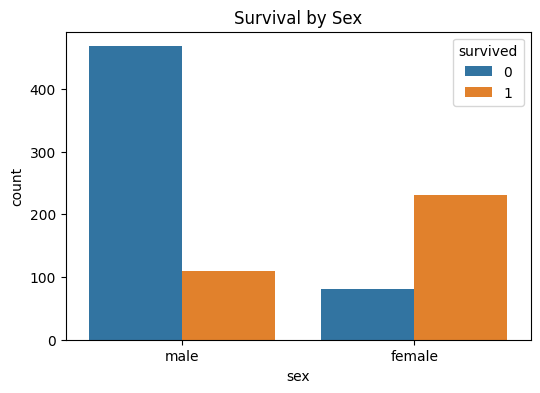

In [18]:
###Chart-2 Survival by Sex
plt.figure(figsize=(6,4))
sns.countplot(x="sex",hue="survived",data=df)
plt.title("Survival by Sex")
plt.show()


Interpretation:
Female passengers had a much higher survival rate than male passengers.This suggests that women were given priority during evacuation

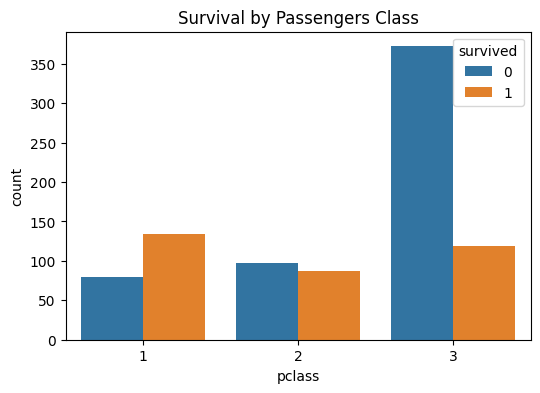

In [19]:
###Chart-3 suvival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x="pclass",hue="survived",data=df)
plt.title("Survival by Passengers Class")
plt.show()

Interpretation:
First-class passengers survived  more often than passengers in the lower classes.Third-class passengers experienced the highest number of deaths.

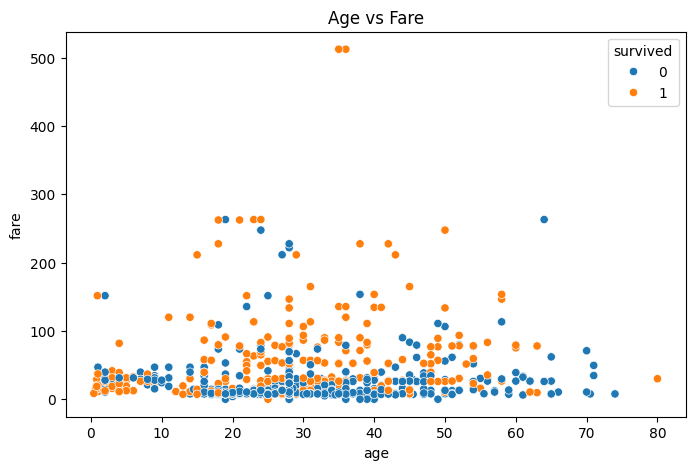

In [20]:
###Chart-4 Fare vs Age
plt.figure(figsize=(8,5))
sns.scatterplot(x="age",y="fare",hue="survived",data=df)
plt.title("Age vs Fare")
plt.show()

interpretation:
passengers who paid higher fares were more likely to survive.There is no strong relationship between age and fare,but survival is more common among passengers with higher fares

In [21]:
###Task-6
###Standardization(Z-score)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[["age","fare"]]=scaler.fit_transform(df[["age","fare"]])
print(df[["age","fare"]].head())



        age      fare
0 -0.563674 -0.500240
1  0.669217  0.788947
2 -0.255451 -0.486650
3  0.438050  0.422861
4  0.438050 -0.484133


In [22]:
### Check Mean and Standard Deviation
print("Mean")
print(df[["age","fare"]].mean())

print("\nStandard Deviation")
print(df[["age","fare"]].std())

Mean
age     2.717486e-16
fare    1.398706e-16
dtype: float64

Standard Deviation
age     1.000563
fare    1.000563
dtype: float64


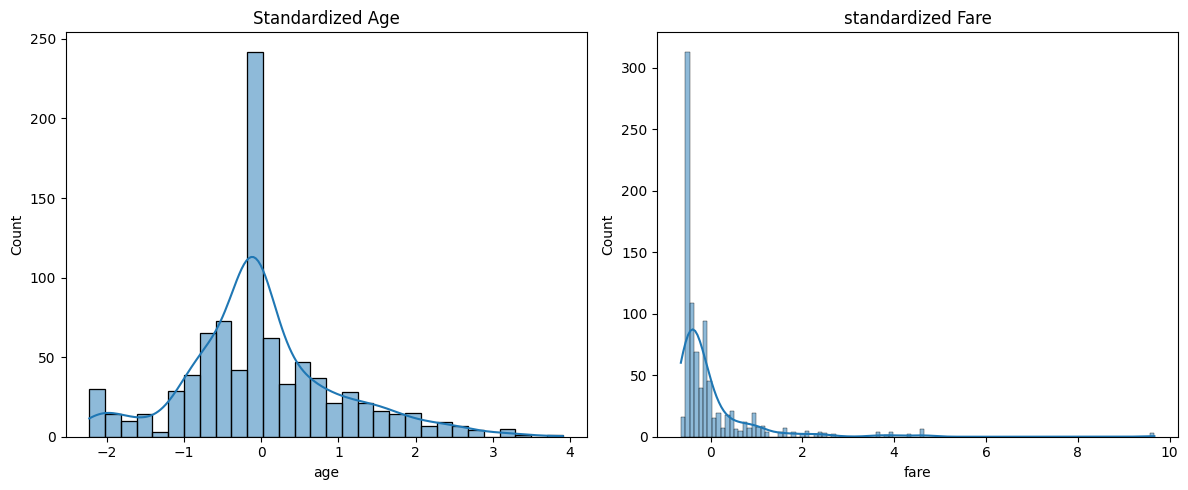

In [23]:
### Before and After Distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["age"],kde=True)
plt.title("Standardized Age")

plt.subplot(1,2,2)
sns.histplot(df["fare"],kde=True)
plt.title("standardized Fare")

plt.tight_layout()
plt.show()

Interpretation
After standardization,both Age and Fare have a mean close to 0 and a standard deviation close to 1.This confirm that the z-score transformation was applied successfully